In [2]:
import pandas as pd

In [3]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name = "E Comm")

In [4]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
df.shape

(5630, 20)

In [6]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [8]:
categorical_numeric_cols = [
    'CityTier',
    'Complain',
    'Churn'
]

for col in categorical_numeric_cols:
    df[col] = df[col].astype('object')

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['CustomerID', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')
Categorical columns: Index(['Churn', 'PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
       'Gender', 'PreferedOrderCat', 'MaritalStatus', 'Complain'],
      dtype='object')


In [10]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [11]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_5687/529649746.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df = df.drop(columns='CustomerID')

In [14]:
rfm_df = df.copy()

In [15]:
rfm_df['R_Score'] = pd.qcut(
    rfm_df['DaySinceLastOrder'],
    q=4,
    labels=[4, 3, 2, 1],
    duplicates='drop'
)

rfm_df['F_Score'] = pd.qcut(
    rfm_df['OrderCount'].rank(method='first'),
    q=4,
    labels=[1, 2, 3, 4],
    duplicates='drop'
)

rfm_df['M_Score'] = pd.qcut(
    rfm_df['CashbackAmount'].rank(method='first'),
    q=4,
    labels=[1, 2, 3, 4],
    duplicates='drop'
)

In [16]:
rfm_df['RFM_Score'] = (
    rfm_df['R_Score'].astype(int) +
    rfm_df['F_Score'].astype(int) +
    rfm_df['M_Score'].astype(int)
)

In [17]:
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 3 and f >= 3 and m >= 3:
        return "High-Value Active Customers"

    elif r >= 3 and f >= 3 and m <= 2:
        return "Frequent Low-Value Customers"

    elif r >= 3 and f <= 2 and m >= 3:
        return "High-Value Occasional Customers"

    elif r >= 3 and f <= 2 and m <= 2:
        return "New and Developing Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "Previously Valuable Customers"

    elif r <= 2 and f >= 3 and m <= 2:
        return "Frequent Customers Losing Interest"

    elif r <= 2 and f <= 2 and m >= 3:
        return "High-Value Customers Losing Interest"

    else:
        return "Inactive Customers"

rfm_df['CustomerSegment'] = rfm_df.apply(segment_customer, axis=1)

In [18]:
rfm_df[['DaySinceLastOrder', 'OrderCount', 'CashbackAmount',
        'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'CustomerSegment']].head()

,DaySinceLastOrder,OrderCount,CashbackAmount,R_Score,F_Score,M_Score,RFM_Score,CustomerSegment
0,5.0,1.0,159.93,2,1,2,5,Inactive Customers
1,0.0,1.0,120.90,4,1,1,6,New and Developing Customers
2,3.0,1.0,120.28,3,1,1,5,New and Developing Customers
3,3.0,1.0,134.07,3,1,1,5,New and Developing Customers
4,3.0,1.0,129.60,3,1,1,5,New and Developing Customers


In [19]:
rfm_df['CustomerSegment'].value_counts()

,count
CustomerSegment,
New and Developing Customers,1323
Previously Valuable Customers,1072
High-Value Active Customers,697
High-Value Occasional Customers,571
Frequent Customers Losing Interest,528
Frequent Low-Value Customers,518
High-Value Customers Losing Interest,475
Inactive Customers,446


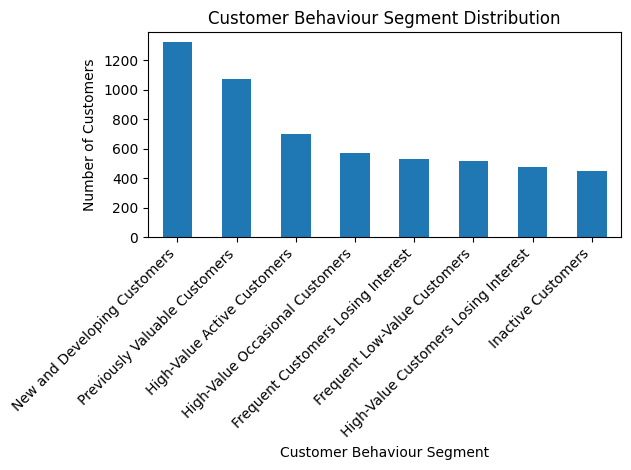

In [22]:
import matplotlib.pyplot as plt

rfm_df['CustomerSegment'].value_counts().plot(kind='bar')
plt.title('Customer Behaviour Segment Distribution')
plt.xlabel('Customer Behaviour Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
rfm_df.to_csv('rfm_segmented_data.csv', index=False)

In [24]:
df = rfm_df.copy()

In [25]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,M_Score_2,M_Score_3,M_Score_4,CustomerSegment_Frequent Low-Value Customers,CustomerSegment_High-Value Active Customers,CustomerSegment_High-Value Customers Losing Interest,CustomerSegment_High-Value Occasional Customers,CustomerSegment_Inactive Customers,CustomerSegment_New and Developing Customers,CustomerSegment_Previously Valuable Customers
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,True,False,False,False,False,False,False,True,False,False
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,False,False,False,False,False,False,False,True,False
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,False,False,False,False,False,False,True,False
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,False,False,False,False,False,False,False,True,False
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,False,False,False,False,False,False,True,False


In [29]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [33]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4504, 46)
X_test shape: (1126, 46)
y_train shape: (4504,)
y_test shape: (1126,)


In [34]:
from imblearn.over_sampling import SMOTE

In [35]:
print(y_train.value_counts())

Churn
0    3746
1     758
Name: count, dtype: int64


In [36]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [37]:
print(y_train_smote.value_counts())

Churn
0    3746
1    3746
Name: count, dtype: int64


In [38]:
print("Original X_train shape:", X_train_scaled.shape)
print("SMOTE X_train shape:", X_train_smote.shape)

print("Original y_train shape:", y_train.shape)
print("SMOTE y_train shape:", y_train_smote.shape)

Original X_train shape: (4504, 46)
SMOTE X_train shape: (7492, 46)
Original y_train shape: (4504,)
SMOTE y_train shape: (7492,)


In [39]:
X_train_smote.to_csv("X_train_smote.csv", index=False)
y_train_smote.to_csv("y_train_smote.csv", index=False)

In [40]:
X_test_scaled.to_csv("X_test_scaled.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [41]:
df.to_csv("processed_churn_data.csv", index=False)

In [42]:
pd.Series(X_train_scaled.columns).to_csv("feature_names.csv", index=False)